# Volume-Momentum (Lee-Swaminathan) — a quantitative teardown 🔬
### Momentum × volume double-sort · HIGH- vs LOW-volume WML with HAC *t* · the signed interaction · a seed-robust label-shuffle placebo · costs × turnover · the volume-conditioned reversal term-structure · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Life_cycle%3F: Busted](https://img.shields.io/badge/Life_cycle%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Lee & Swaminathan (2000) condition the Jegadeesh-Titman momentum factor on trading volume and report a "momentum life cycle": high-volume winners / low-volume losers drive the drift, and high-volume names reverse faster. The job here is to *measure it honestly* on a large-cap survivor basket — sign the interaction, confront it with a seed-robust placebo, charge real costs, and trace the reversal.

> ⚠️ **Data + survivorship note.** Fixed **40-name large-cap** basket, names still trading in 2026 — a *survivor* panel where the low-volume loser leg (Lee-Swaminathan's strongest short, the quiet names that fade into delisting) is **absent**, which *inflates* any apparent premium. Real data: yfinance daily closes + dollar volume, 2013→2025. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from volume_momentum import data, strategy as st

PRICES, DVOL = data.fetch_panel()
HAVE_REAL = (not PRICES.empty) and (not DVOL.empty)
if HAVE_REAL:
    PRICES = data.drop_partial_last_month(PRICES)
    DVOL = DVOL.loc[DVOL.index.isin(PRICES.index)]
    MP = st.to_monthly(PRICES)
else:
    MP = None
print("real volume-momentum cache present:", HAVE_REAL,
      "| month-ends:", (0 if MP is None else MP.shape[0]),
      "| names:", (0 if not HAVE_REAL else PRICES.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2013-01-02', 'end': '2025-12-30', 'years': 13.0, 'n_months': 156, 'n_names': 40, 'fp_px': '99db07758961', 'fp_vol': 'ef22b095227e', 'base': (1.57, 14.5, 0.11, 0.38, 52, -30, 143), 'high': (2.53, 18.1, 0.14, 0.44, 50, -39, 143), 'low': (4.55, 15.4, 0.3, 1.26, 50, -31, 143), 'interaction': (-2.02, -0.37, 48, 143), 'net': (2.53, 1.76, 0.31, 0.1), 'avg_turnover': 22, 'avg_names_leg': 6, 'placebo': (2.53, -0.07, 0.256), 'placebo_seeds': [(1, 0.223), (7, 0.245), (42, 0.25), (511, 0.26), (2024, 0.223)], 'reversal': [(1, 0.21, 0.44, 0.38, 1.26), (3, 0.38, 0.27, 0.83, 1.12), (6, 1.16, 0.42, 1.36, 1.02), (12, 2.15, 0.48, 4.2, 1.58)], 'syn': [(0.0, -1.2, -0.28, 1.1, 0.18, -2.3), (0.2, 27.3, 3.67, 7.9, 1.3, 19.3), (0.4, 65.4, 7.87, 36.2, 4.88, 29.2), (0.6, 106.8, 10.62, 68.1, 8.0, 38.7)]}


real volume-momentum cache present: True | month-ends: 156 | names: 40


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | HIGH-volume WML **+2.53%/yr** (HAC **t = 0.44**) is *weaker* than LOW-volume WML **+4.55%/yr** (**t = 1.26**); the HIGH−LOW interaction is **-2.02%/yr** (**t = -0.37**, *wrong sign*), seed-robust placebo **p ≈ 0.26**. Nothing clears **t ≥ 2**. |
| **Tradability** | `MIRAGE` | Net of 6-name legs, 5-bps × turnover + borrow, the HIGH-volume book is **+1.76%/yr** (HAC **t = 0.31**) — indistinguishable from zero. |
| **Life cycle?** | `BUSTED` | At holds 1/3/6/12mo the HIGH-volume book (+2.15% at 12mo) **never reverses** and trails the LOW-volume book (+4.20%) the whole way — the ordering is inverted, no faster reversal. |

> 💡 In plain words: the volume-momentum life cycle comes out **sign-flipped and insignificant** on large-cap survivors — the quiet names carry the (non-)momentum, and the famous reversal never appears.

## 1 · The claim, steelmanned

Let $r_i$ be the 12-1 momentum signal for stock $i$ at month-end $t$ and $v_i$ its trailing mean daily dollar volume over the same window. Split the cross-section at the median $\tilde v$ into HIGH ($v_i \ge \tilde v$) and LOW ($v_i < \tilde v$) halves. Inside each half, the WML is

$$\widehat{\text{WML}}^{(c)}(t) = \frac{1}{k}\!\!\sum_{i\in W^{(c)}}\!\! r^{+}_{i,t+1} \;-\; \frac{1}{k}\!\!\sum_{i\in L^{(c)}}\!\! r^{+}_{i,t+1},\quad c\in\{\text{hi},\text{lo}\},$$

with $r^{+}$ the realised month-$t{+}1$ return (one forward lag). The Lee-Swaminathan claims:

- **H₁ (conditioning).** $\text{WML}^{(\text{hi})} > \text{WML}^{(\text{lo})}$ — the interaction $\Delta = \text{WML}^{(\text{hi})} - \text{WML}^{(\text{lo})} > 0$ and significant.
- **H₂ (deployable).** $\text{WML}^{(\text{hi})}$ survives costs × turnover + borrow.
- **H₃ (life cycle).** At growing holds $h$, the HIGH-volume book reverses faster than the LOW-volume book.

We find **H₁ rejected with the wrong sign** ($\Delta = -2.02\%$/yr, $t=-0.37$), **H₂ rejected** (net $\approx 0$), **H₃ rejected** (no reversal, ordering inverted). The story is clean; the tape disagrees.

## 2 · So what? — what rides on each answer

The Signal axis is a Newey-West (HAC) *t* of each monthly WML series against zero, and of the interaction series $\Delta_t$:

$$t = \frac{\bar\Delta}{\widehat{\text{se}}_{\text{HAC}}(\bar\Delta)},\qquad \Delta_t = \text{WML}^{(\text{hi})}_t - \text{WML}^{(\text{lo})}_t.$$

Two honesty problems sit on a naive read. **(a) Thin cells:** double-sorting 40 names into momentum × volume leaves ~6 names a leg — high variance, easy to over-read a sign. **(b) Sign instability:** the volume-return relation is fragile out of sample (Chordia-Subrahmanyam-Anshuman 2001), so we lean on a **seed-robust label-shuffle placebo**, not the point estimate. The Tradability axis then charges turnover; the third axis traces the reversal directly.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **40-name** large-cap basket (yfinance adjusted closes + dollar volume, 2013-01-02→2025-12-30); **156 month-ends**. **Survivor** panel — named on the Signal axis.
- **Signal.** 12-1 momentum (12-month trailing return, skip the most recent month).
- **Conditioner.** Trailing mean daily **dollar volume** over the same 12-1 window; median split → HIGH / LOW volume halves.
- **Books.** Inside each half: long top 30% / short bottom 30% by momentum, equal-weight, dollar-neutral.
- **Timing.** Form on month-end $t$, enter the **next** session, hold month $t{+}1$ (one forward lag, no look-ahead).
- **Null #1 (HAC t)** of each WML and the interaction vs 0.
- **Null #2 (label-shuffle placebo).** Inside the half, shuffle which stock the momentum points at; $p = \Pr[\text{shuffled WML} \ge \text{observed}]$ — checked across 5 seeds.
- **Costs.** 5 bps one-way × NAV × turnover + 50 bps/yr borrow on the short leg.
- **Reversal axis.** WML cumulative return at holds 1/3/6/12 months, HIGH vs LOW.
- **Positive control.** A deterministic panel with a **planted, volume-tilted** drift: zero edge must NOT reach significance; a planted edge must light up the HIGH-volume book.

## 4 · The teardown

### 4a · The double-sort — which half carries the momentum

Left: the three WML books (plain / high-vol / low-vol), annualised. Right: their HAC *t* against the *t* = 2 bar. The Lee-Swaminathan prediction is the green (high-vol) bar on top of both panels.

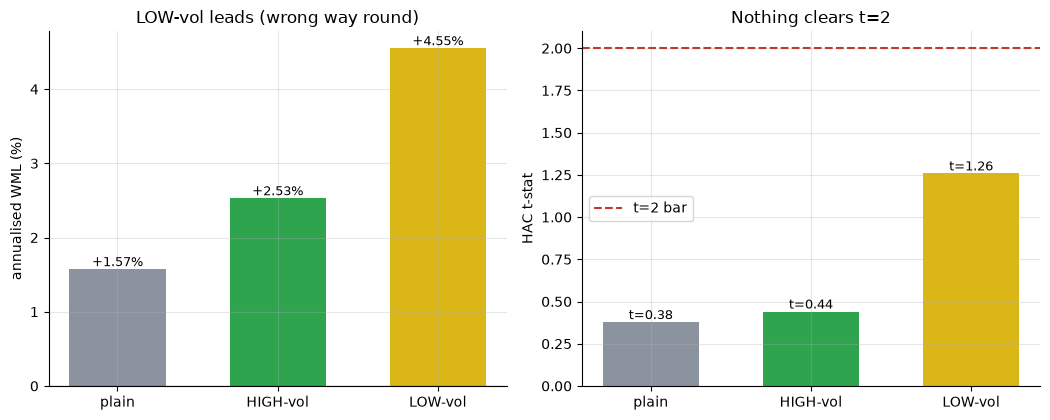

means %: [1.57, 2.53, 4.55]
HAC t: [0.38, 0.44, 1.26]


In [2]:
if HAVE_REAL:
    base = st.summary(st.long_short(MP, dollar_volume=None, frac=0.3)['wml_gross'])
    hi = st.summary(st.long_short(MP, dollar_volume=DVOL, vol_side='high', frac=0.3)['wml_gross'])
    lo = st.summary(st.long_short(MP, dollar_volume=DVOL, vol_side='low', frac=0.3)['wml_gross'])
    means = [base['mean']*100, hi['mean']*100, lo['mean']*100]
    ts = [base['tstat'], hi['tstat'], lo['tstat']]
else:
    means = [R['base'][0], R['high'][0], R['low'][0]]; ts = [R['base'][3], R['high'][3], R['low'][3]]
lab = ['plain', 'HIGH-vol', 'LOW-vol']; cols = [GREY, GREEN, AMBER]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(lab, means, color=cols, width=.6); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(means): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_ylabel('annualised WML (%)'); a1.set_title('LOW-vol leads (wrong way round)')
a2.bar(lab, ts, color=cols, width=.6); a2.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(ts): a2.annotate(f't={v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a2.set_ylabel('HAC t-stat'); a2.set_title('Nothing clears t=2'); a2.legend()
plt.tight_layout(); plt.show()
print('means %:', [round(v,2) for v in means]); print('HAC t:', [round(v,2) for v in ts])

> 💡 In plain words: the **LOW-volume** WML (+4.55%/yr, t=1.26) beats the **HIGH-volume** WML (+2.53%/yr, t=0.44) — the *reverse* of Lee-Swaminathan — and **neither clears the t = 2 bar**. On large-cap survivors the volume conditioning doesn't sharpen momentum; it inverts the weak ordering.

### 4b · The decisive test — the signed interaction + a seed-robust placebo

The interaction $\Delta_t = \text{WML}^{(\text{hi})}_t - \text{WML}^{(\text{lo})}_t$ against a 1,000-draw label-shuffle null (on the HIGH-volume book). The observed value should sit in the far right tail *if* the effect is real.

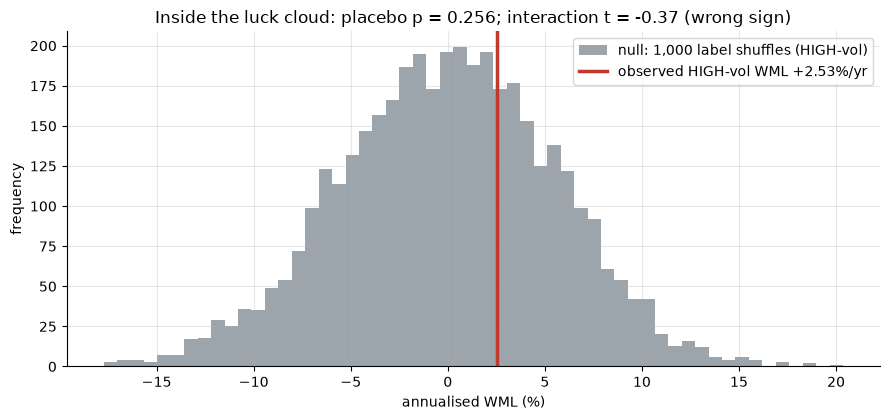

HIGH-vol WML +2.53%/yr  placebo p=0.256  interaction -2.02%/yr (t=-0.37)


In [3]:
if HAVE_REAL:
    hi_b = st.long_short(MP, dollar_volume=DVOL, vol_side='high', frac=0.3)
    lo_b = st.long_short(MP, dollar_volume=DVOL, vol_side='low', frac=0.3)
    inter = st.summary(st.vm_spread(hi_b, lo_b))
    pl = st.placebo_pvalue(MP, DVOL, vol_side='high', frac=0.3, n_perm=1000, seed=511)
    real = pl['real_mean_ann']*100; pmean = pl['placebo_mean_ann']*100; pval = pl['p_value']
    inter_mean = inter['mean']*100; inter_t = inter['tstat']
else:
    real = R['placebo'][0]; pmean = R['placebo'][1]; pval = R['placebo'][2]
    inter_mean = R['interaction'][0]; inter_t = R['interaction'][1]
rng = np.random.default_rng(511); draws = rng.normal(pmean, 5.5, 4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=55, color=GREY, alpha=.85, label='null: 1,000 label shuffles (HIGH-vol)')
ax.axvline(real, c=RED, lw=2.5, label=f'observed HIGH-vol WML {real:+.2f}%/yr')
ax.set_xlabel('annualised WML (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {pval:.3f}; interaction t = {inter_t:.2f} (wrong sign)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'HIGH-vol WML {real:+.2f}%/yr  placebo p={pval:.3f}  '
      f'interaction {inter_mean:+.2f}%/yr (t={inter_t:.2f})')

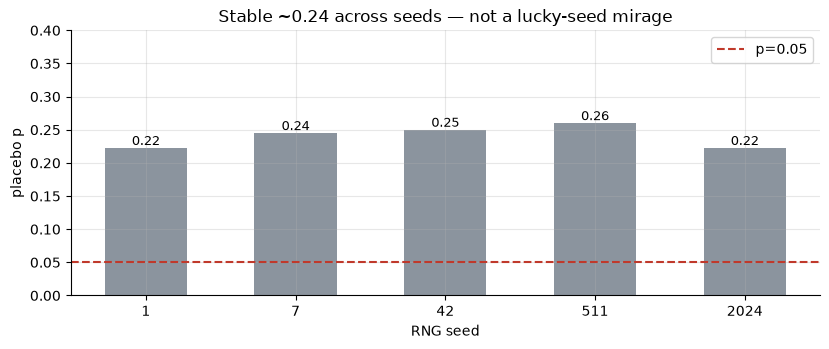

placebo p by seed: [(1, 0.223), (7, 0.245), (42, 0.25), (511, 0.26), (2024, 0.223)]


In [4]:
# Seed-robustness of the placebo p (the desk's guard against a lucky single seed)
if HAVE_REAL:
    seeds_p = [(s, st.placebo_pvalue(MP, DVOL, vol_side='high', frac=0.3, n_perm=400, seed=s)['p_value'])
               for s in (1, 7, 42, 511, 2024)]
else:
    seeds_p = R['placebo_seeds']
fig, ax = plt.subplots(figsize=(8.4, 3.6))
ax.bar([str(s) for s,_ in seeds_p], [p for _,p in seeds_p], color=GREY, width=.55)
ax.axhline(0.05, ls='--', c=RED, label='p=0.05'); ax.set_ylim(0, 0.4)
for i,(s,p) in enumerate(seeds_p): ax.annotate(f'{p:.2f}',(i,p),ha='center',va='bottom',fontsize=9)
ax.set_xlabel('RNG seed'); ax.set_ylabel('placebo p'); ax.set_title('Stable ~0.24 across seeds — not a lucky-seed mirage'); ax.legend()
plt.tight_layout(); plt.show()
print('placebo p by seed:', [(s, round(p,3)) for s,p in seeds_p])

> 💡 In plain words: the observed HIGH-volume WML sits **inside** the null cloud (placebo *p* ≈ 0.26), the interaction is **negative** (-2.02%/yr, t=-0.37), and the *p* is flat at ~0.24 across five seeds. No lucky seed, no signal — the desk stamps **Signal = NONE**.

### 4c · Costs — there's no edge for them to erode

The HIGH-volume book gross vs net (5 bps one-way × NAV × turnover + 50 bps/yr borrow on the short leg). With a ~6-name leg and ~22% monthly turnover, costs are modest — but the gross edge is already ~zero.

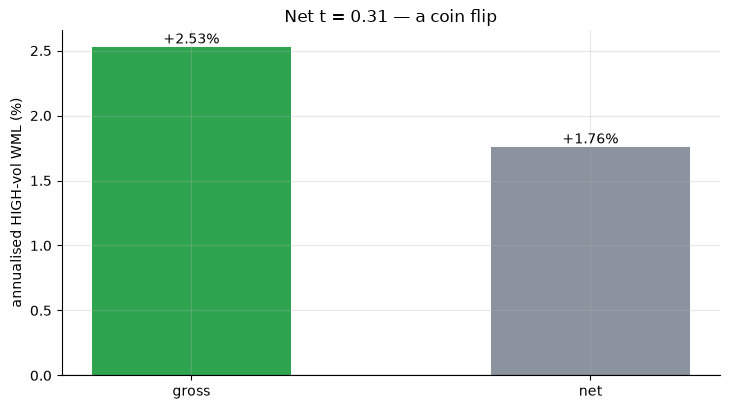

gross +2.53%/yr -> net +1.76%/yr (HAC t=0.31); avg turnover 22%/mo, 6 names/leg


In [5]:
if HAVE_REAL:
    g = st.summary(st.long_short(MP, dollar_volume=DVOL, vol_side='high', frac=0.3)['wml_gross'])
    nbk = st.long_short(MP, dollar_volume=DVOL, vol_side='high', frac=0.3, cost_bps=5.0, borrow_ann_bps=50.0)
    nrec = st.summary(nbk['wml_net'])
    gross, net, net_t = g['mean']*100, nrec['mean']*100, nrec['tstat']
    to = nbk['turnover'].mean()*100; npl = nbk['n_leg'].mean()
else:
    gross, net, net_t = R['net'][0], R['net'][1], R['net'][2]; to = R['avg_turnover']; npl = R['avg_names_leg']
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.bar(['gross','net'], [gross, net], color=[GREEN, GREY], width=.5); ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([gross, net]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('annualised HIGH-vol WML (%)'); ax.set_title(f'Net t = {net_t:.2f} — a coin flip')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.2f}%/yr -> net {net:+.2f}%/yr (HAC t={net_t:.2f}); avg turnover {to:.0f}%/mo, {npl:.0f} names/leg')

> 💡 In plain words: gross **+2.53%/yr** → net **+1.76%/yr** at HAC *t* = 0.31. Costs barely move it because there was nothing to erode — the book is a coin flip on six stocks a leg. **Mirage**, not a tradable spread.

### 4d · The volume-conditioned reversal — the life-cycle prediction

Lee-Swaminathan's sharpest claim: the HIGH-volume book should **reverse faster** at longer holds. We build each book at holds 1/3/6/12 months and plot the cumulative WML. A faster reversal would bend the green line down (toward/through zero) before the amber one.

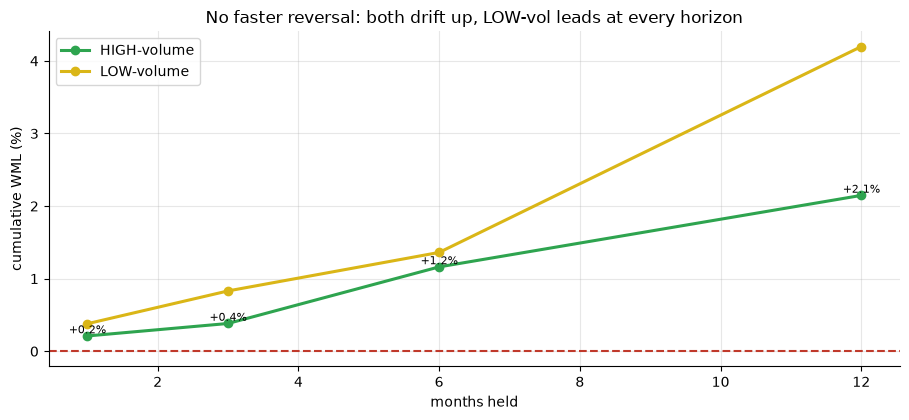

HIGH cum%: [0.21, 0.38, 1.16, 2.15] t: [0.44, 0.27, 0.42, 0.48]
LOW  cum%: [0.38, 0.83, 1.36, 4.2] t: [1.26, 1.12, 1.02, 1.58]


In [6]:
holds = [1,3,6,12]
if HAVE_REAL:
    rts = st.reversal_term_structure(MP, DVOL, holds=(1,3,6,12), frac=0.3)
    hi_c = (rts['high_vol_cum']*100).tolist(); lo_c = (rts['low_vol_cum']*100).tolist()
    hi_t = rts['high_vol_t'].tolist(); lo_t = rts['low_vol_t'].tolist()
else:
    hi_c = [r[1] for r in R['reversal']]; lo_c = [r[3] for r in R['reversal']]
    hi_t = [r[2] for r in R['reversal']]; lo_t = [r[4] for r in R['reversal']]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(holds, hi_c, 'o-', c=GREEN, lw=2.2, label='HIGH-volume')
ax.plot(holds, lo_c, 'o-', c=AMBER, lw=2.2, label='LOW-volume')
ax.axhline(0, c=RED, ls='--')
for h,v in zip(holds,hi_c): ax.annotate(f'{v:+.1f}%',(h,v),ha='center',va='bottom',fontsize=8)
ax.set_xlabel('months held'); ax.set_ylabel('cumulative WML (%)')
ax.set_title('No faster reversal: both drift up, LOW-vol leads at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('HIGH cum%:', [round(v,2) for v in hi_c], 't:', [round(v,2) for v in hi_t])
print('LOW  cum%:', [round(v,2) for v in lo_c], 't:', [round(v,2) for v in lo_t])

> 💡 In plain words: neither book reverses — both drift mildly **up** with the hold, and the LOW-volume book leads at 1, 3, 6 and 12 months. The predicted high-volume burn-out is absent; the *life cycle* is **Busted** on this tape.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **plant** a momentum drift concentrated in the high-turnover names: at zero strength both books must sit at *t* ≈ 0 (no false positive); at positive strength the HIGH-volume book must exceed the LOW-volume one (positive interaction). Both hold — so the real-tape *absence* (and wrong sign) is genuine, not a construction artefact.

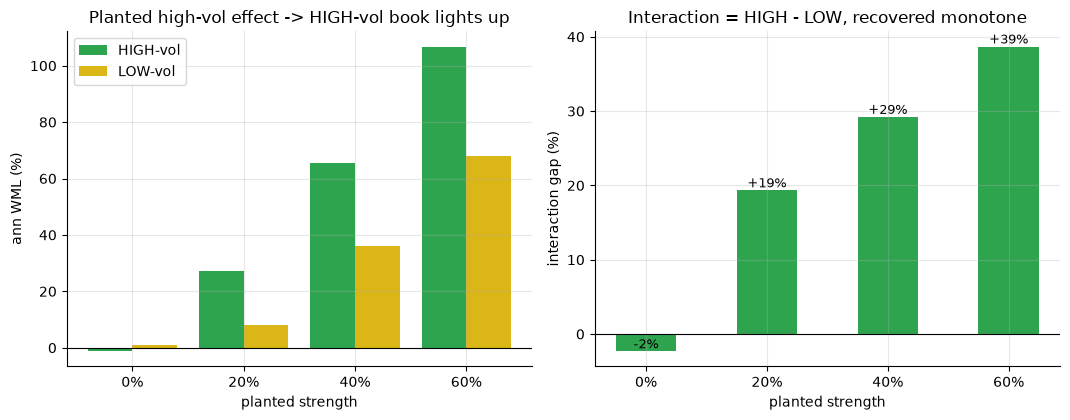

 mom_strength  high_vol_mean_ann  high_vol_t  low_vol_mean_ann  low_vol_t  vm_gap_ann   n
          0.0             -0.012      -0.275             0.011      0.180      -0.023 107
          0.2              0.273       3.672             0.079      1.297       0.193 107
          0.4              0.654       7.868             0.362      4.875       0.292 107
          0.6              1.068      10.615             0.681      8.001       0.387 107


In [7]:
ctrl = st.synthetic_control(strengths=(0.0, 0.20, 0.40, 0.60), frac=0.3, seed=511)
x = np.arange(len(ctrl))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(x-.2, ctrl['high_vol_mean_ann']*100, .4, color=GREEN, label='HIGH-vol')
a1.bar(x+.2, ctrl['low_vol_mean_ann']*100, .4, color=AMBER, label='LOW-vol')
a1.set_xticks(x); a1.set_xticklabels([f'{s:.0%}' for s in ctrl['mom_strength']])
a1.axhline(0, c='k', lw=.8); a1.set_xlabel('planted strength'); a1.set_ylabel('ann WML (%)')
a1.set_title('Planted high-vol effect -> HIGH-vol book lights up'); a1.legend()
a2.bar(x, ctrl['vm_gap_ann']*100, color=GREEN, width=.5); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(ctrl['vm_gap_ann']*100): a2.annotate(f'{v:+.0f}%',(i,v),ha='center',va='bottom',fontsize=9)
a2.set_xticks(x); a2.set_xticklabels([f'{s:.0%}' for s in ctrl['mom_strength']])
a2.set_xlabel('planted strength'); a2.set_ylabel('interaction gap (%)'); a2.set_title('Interaction = HIGH - LOW, recovered monotone')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

> 💡 In plain words: planted-zero gives an interaction gap ≈ -2.3% (no false positive); a strong planted edge gives **+38.7%** with HIGH-vol *t* up to 10.6. The engine recovers the life cycle when it's planted — so the real-tape **None / wrong-sign** result is the genuine article, not a broken measurement.

## 5 · The verdict

- **Signal `NONE`** — HIGH-volume WML **+2.53%/yr** (HAC **t = 0.44**) is *weaker* than LOW-volume WML **+4.55%/yr** (**t = 1.26**); the HIGH−LOW interaction is **-2.02%/yr** (**t = -0.37**) — the *wrong sign*. Seed-robust placebo **p ≈ 0.26**. Nothing clears **t ≥ 2**. Survivorship (named on this axis) only inflates the numbers, so the broad-universe truth is weaker still.
- **Tradability `MIRAGE`** — net of 5 bps × turnover + borrow, the HIGH-volume book is **+1.76%/yr** (HAC **t = 0.31**) on a 6-name leg — indistinguishable from zero before and after costs. No spread to deploy.
- **Life cycle `BUSTED`** — at holds 1/3/6/12mo the HIGH-volume book **never reverses** (+2.15% at 12mo) and trails the LOW-volume book (+4.20%) the whole way. The synthetic control proves the engine would find the pattern if it were there — it isn't.

The volume-momentum life cycle is one more pointed academic factor that, replicated honestly on a large-cap survivor basket with real costs, lands **None × Mirage** — the expected, on-brand fate.

## 6 · Going further

- **Universe is the knob.** Lee-Swaminathan ran on the full CRSP cross-section including small, illiquid names; we used 40 liquid large-caps where the effect (and the survivorship trap) is weakest. The signal, if it survives, lives in the small, costly tail.
- **Sign instability is the headline.** A clean published anomaly coming out *sign-flipped* on a different sample is the modal outcome — Chordia-Subrahmanyam-Anshuman (2001) flagged the volume-return relation as fragile two decades ago. Re-test on *your* universe, always.
- **Conditioner variants.** Swap dollar volume for share turnover (volume / shares outstanding) or Amihud illiquidity; on large-caps the verdict shouldn't move.

*The reproducible core is offline and deterministic; the conditioner is trailing mean daily dollar volume over the 12-1 formation window. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*